# 01.MS spectra 

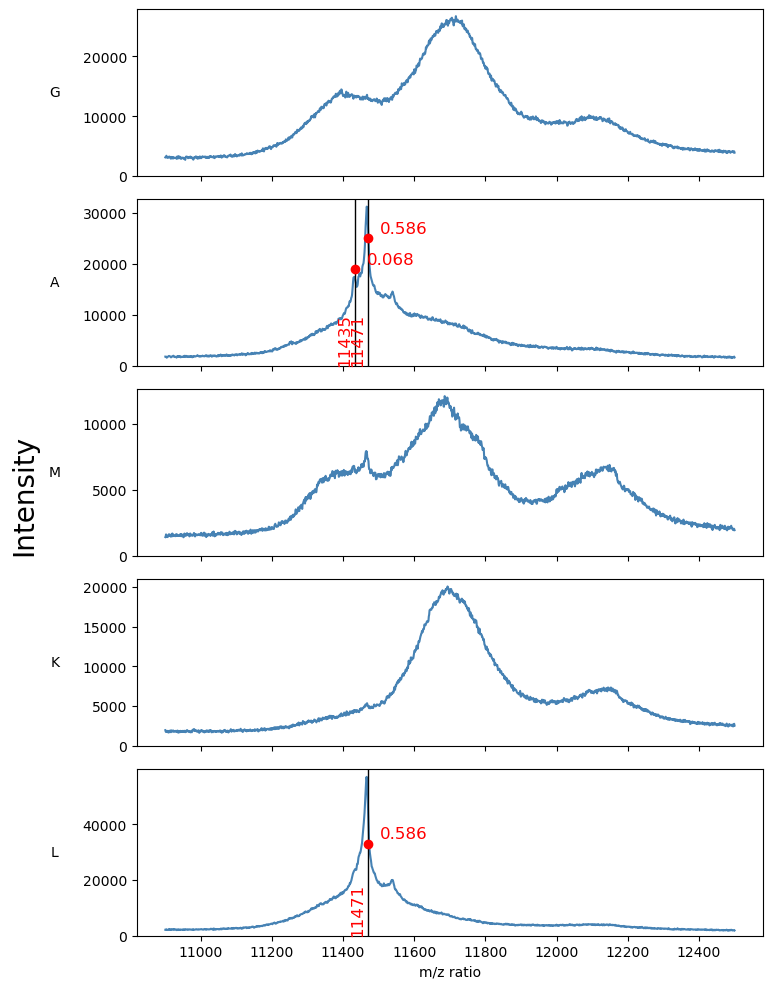

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.load('../data/22051100_MSXXXX794.npy')

labels = ["G", "A", "M", "K", "L"]
highlight_mz = [11435, 11471]
highlight_vals = [0.068, 0.586]  

fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

for i in range(5):
    mz = data[0, i, :].astype(float)
    intensity = data[1, i, :].astype(float)
    axes[i].plot(mz, intensity, color='steelblue')
    axes[i].set_ylabel(labels[i], rotation=0, labelpad=20, va='center')
    axes[i].set_ylim(bottom=0)

    label_font_size = 12
    if labels[i] == "A":
        for j, (m, y_text) in enumerate(zip(highlight_mz, highlight_vals)):
            y_offset = 20000 + j * 6000  # 15000, 25000 ...
            axes[i].axvline(x=m, color='black', linestyle='-', linewidth=1)
            axes[i].plot(m, y_offset-1000, 'o', color='red')
            axes[i].text(m+100, y_offset, f"{y_text:.3f}", color='red', fontsize=label_font_size, ha='center')
            axes[i].text(m-30, 0, f"{int(m)}", color='red', fontsize=label_font_size, ha='center', va='bottom', rotation=90)

    elif labels[i] == "L":
        m = highlight_mz[1]
        y_text = highlight_vals[-1]
        axes[i].axvline(x=m, color='black', linestyle='-', linewidth=1)
        axes[i].plot(m, 35000-2000, 'o', color='red')
        axes[i].text(m+100, 35000, f"{y_text:.3f}", color='red', fontsize=label_font_size, ha='center')
        axes[i].text(m-30, 0, f"{int(m)}", color='red', fontsize=label_font_size, ha='center', va='bottom', rotation=90)

axes[-1].set_xlabel("m/z ratio")
fig.text(0.04, 0.5, 'Intensity', va='center', rotation='vertical', fontsize=20)
plt.tight_layout(rect=[0.07, 0, 1, 1])
plt.savefig(f'../00.Figures/PCROWD_MM_MassSpect_spectra.pdf', format='pdf', bbox_inches='tight')
plt.show()



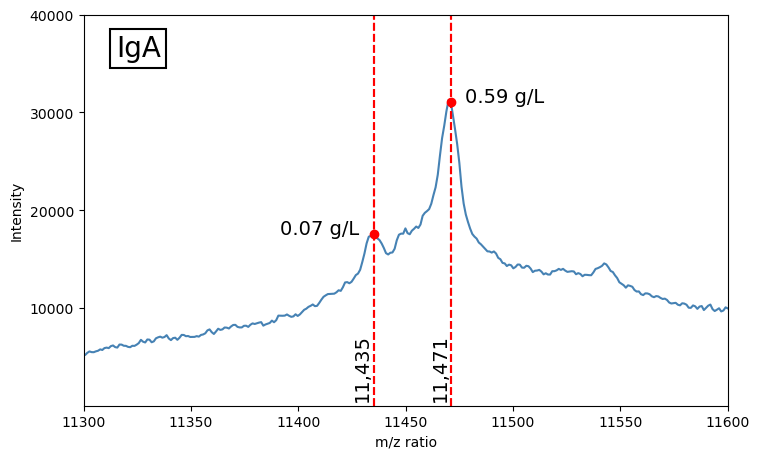

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('../data/22051100_MSXXXX794.npy') ## Raw, not re-calibrated data
labels = ["G", "A", "M", "K", "L"]

fig, ax = plt.subplots(figsize=(8, 5)) 
plt.rcParams.update({'font.size': 20})

i = 1  
mz = data[0, i, :].astype(float) + 3.5 ## manually recalibrate
intensity = data[1, i, :].astype(float)

ax.plot(mz, intensity, color='steelblue')
ax.set_ylabel('Intensity')
ax.set_xlabel("m/z ratio")
ax.set_ylim(bottom=0)

# Red vertical lines at specific m/z
for xline in [11435, 11471]:
    ax.axvline(x=xline, color='red', linestyle='--', linewidth=1.5)

# Optional: Customize x-axis range
ax.set_xlim(11300, 11600)  

highlight_mz = [11435, 11471]
highlight_vals = [0.068, 0.586]

for j, (m, y_text) in enumerate(zip(highlight_mz, highlight_vals)):
    ax.axvline(x=m, color='red', linestyle='--', linewidth=1.5)
    y_offset = 17550 + j * 13500  # 15000, 25000 ...
    ax.plot(m, y_offset, 'o', color='red')
    if j == 0:
        ax.text(m-25, y_offset, f"{y_text:.2f} g/L", color='black', fontsize=14, ha='center')
    else:
        ax.text(m+25, y_offset, f"{y_text:.2f} g/L", color='black', fontsize=14, ha='center')
    ax.text(m-5, 500, f"{int(m):,}", color='black', fontsize=14,
            ha='center', va='bottom', rotation=90)

ax.text(
    0.05, 0.95, "IgA",
    transform=ax.transAxes,
    fontsize=20,
    #fontweight='bold',
    ha='left',
    va='top',
    bbox=dict(facecolor='none', edgecolor='black',  linewidth=1.5)
) 

yticks = ax.get_yticks()
yticks_no_zero = [tick for tick in yticks if tick != 0]
ax.set_yticks(yticks_no_zero)

plt.tight_layout()
plt.savefig(f'../00.Figures/PCROWD_MM_MassSpect_spectra_IgA.pdf', format='pdf', bbox_inches='tight')
plt.show()


# 02. Reconstruct MS spectra

[11442.57598079 11478.56105061]


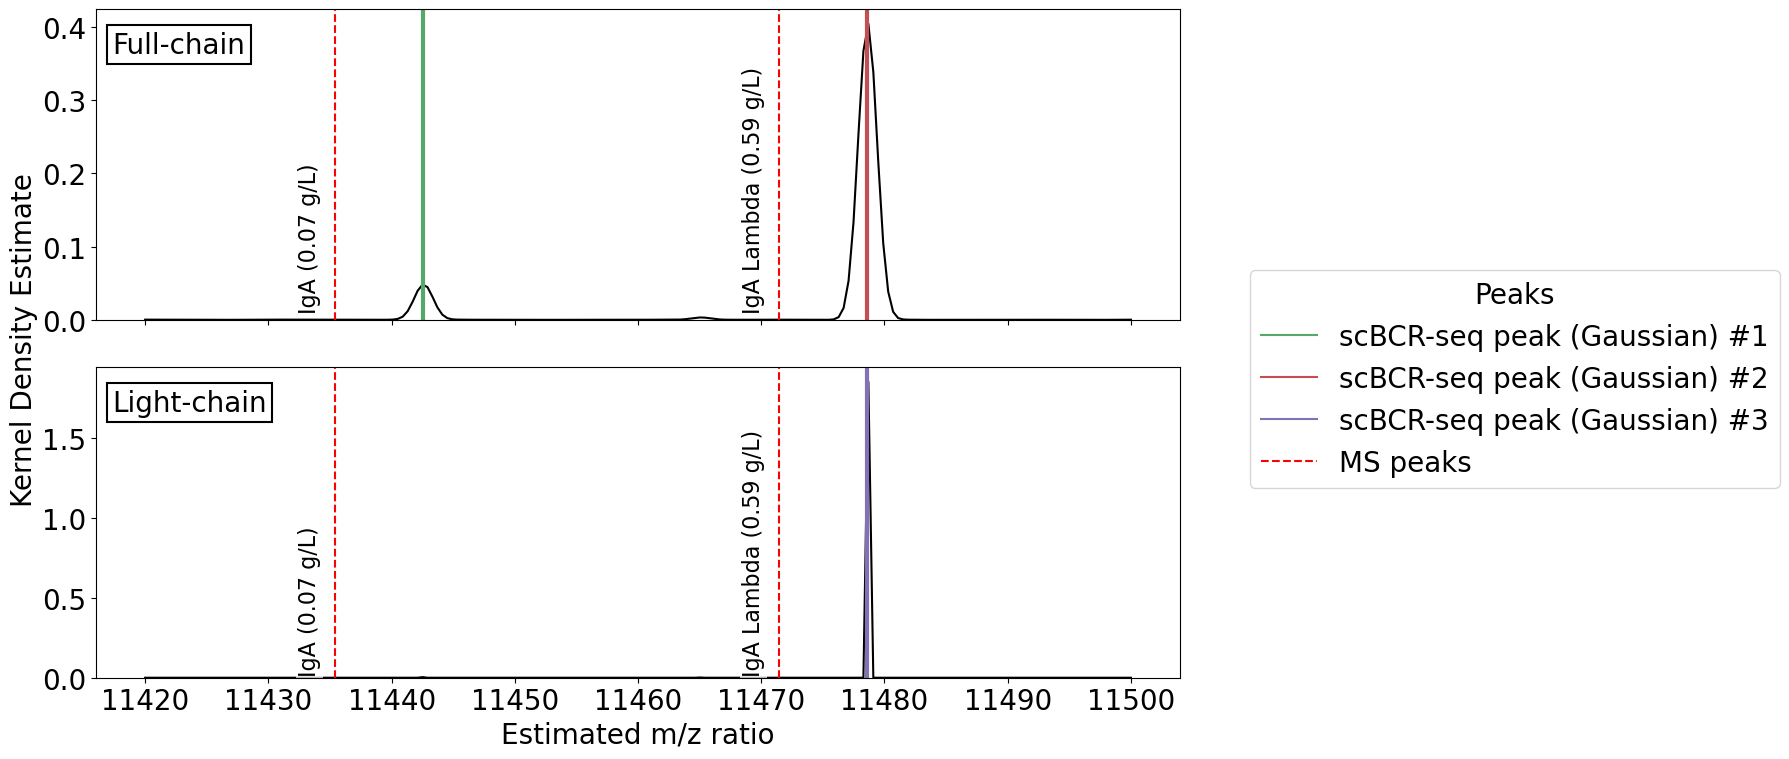

In [10]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import colorcet as cc
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks


heavy_chain_dict = {
    "IGHM" : "IgM",
    "IGHA" : "IgA",
    "IGHG" : "IgG"
}

light_chain_dict = {
    "IGLC" : "Lambda",
    "IGKC" : "Kappa"
}

ms_results = [
    'IGHA_IGLC:11471.47127:0.586:2:Plasma:nan:nan:nan',
    'IGHA:11435.401:0.068:2:Plasma:nan:nan:nan',
    
]


input_df = pd.read_csv('../data/PCROWD_MM_BCR.csv', sep=",")
input_df = input_df.dropna(subset=['est_mz_ratio'])

x_values = []
annotations = []

for item in ms_results:
    parts = item.split(":")
    isotype, ms_mz_ratio, conc = parts[0], parts[1], parts[2]
    if "_" in isotype:
        hc, lc = isotype.split("_")
        heavy_chain = heavy_chain_dict[hc]
        light_chain = light_chain_dict[lc]
        isotype_final = heavy_chain + " " + light_chain
    else:
        isotype_final = heavy_chain_dict[isotype]
    x_values.append(float(ms_mz_ratio))
    annotations.append(f"{isotype_final} ({float(conc):.2f} g/L)")


# Compute KDE manually to find peaks
kde = gaussian_kde(input_df['est_mz_ratio'], bw_method=0.1)
x_range = np.linspace(input_df['est_mz_ratio'].min(), input_df['est_mz_ratio'].max(), 5000)
y_kde = kde(x_range)

# Find peaks in the KDE
peaks_indices, _ = find_peaks(y_kde, prominence=0.001, distance=10)  
peaks_x = x_range[peaks_indices]
peaks_y = y_kde[peaks_indices]
print(peaks_x)

#     # Fill shade in +-3 of gaussian peak
#     for peak in peaks_x:
#         mask = (x_range >= peak - 3) & (x_range <= peak + 3)
#         plt.fill_between(x_range, 0, y_kde, where=mask, color='grey', alpha=0.4)


# Split the dataframe
df_not_nan = input_df[input_df['heavy_c_gene_all_contig'].notna()]
df_nan = input_df[input_df['heavy_c_gene_all_contig'].isna()]

# Create subplots (top: not-nan, bottom: nan)
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[1, 1])

clip = (11420, 11500)

### Top plot: heavy_c_gene_all_contig is NOT NaN
sns.kdeplot(
    df_not_nan['est_mz_ratio'],
    fill=False,
    color='black',
    clip=clip,
    bw_adjust=0.05,
    ax=axes[0]
)

# Common colors for MS peaks
colors = sns.color_palette("deep", 5)
#type_colors = {≥0.2g/L' : colors[3], 'LC only' : colors[4], '<0.2g/L' : colors[2],}

axes[0].axvline(x=peaks_x[0], color=colors[2], linestyle='-', alpha=1, linewidth=3)
axes[0].axvline(x=peaks_x[-1], color=colors[3], linestyle='-', alpha=1, linewidth=3)

axes[0].set_ylabel("")

### Bottom plot: heavy_c_gene_all_contig IS NaN
sns.kdeplot(
    df_nan['est_mz_ratio'],
    fill=False,
    color='black',
    clip=clip,
    bw_adjust=0.01,
    ax=axes[1]
)

axes[1].axvline(x=peaks_x[-1], color=colors[4], linestyle='-', alpha=1, linewidth=3)

axes[1].set_ylabel("")
axes[1].set_xlabel("Estimated m/z ratio")
#axes[1].set_title("Without heavy chain isotype (NaN)")

# Add chain status
axes[0].text(
    0.015, 0.93, "Full-chain",
    transform=axes[0].transAxes,
    ha='left', va='top',
    #fontsize=20,
    bbox=dict(facecolor='none', edgecolor='black',  linewidth=1.5)
)

axes[1].text(
    0.015, 0.93, "Light-chain",
    transform=axes[1].transAxes,
    ha='left', va='top',
    #fontsize=20,
    bbox=dict(facecolor='none', edgecolor='black',  linewidth=1.5)
)

# MS annotation
for x, label in zip(x_values, annotations):
    for ax in axes:
        ax.axvline(x=x, color='red', linestyle='--', alpha=1)

        ax.text(
            x - 3,                      
            ax.get_ylim()[0] + 0.01,   
            label,                 
            rotation=90,           
            color='black',
            fontsize=16,
            ha='left',
            va='bottom',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1.5)  
        )

# Shared legend outside the plot
custom_lines = (
    [plt.Line2D([0], [0], color=colors[2], linestyle='-', label='scBCR-seq peak (Gaussian) #1')] +
    [plt.Line2D([0], [0], color=colors[3], linestyle='-', label='scBCR-seq peak (Gaussian) #2')] +
    [plt.Line2D([0], [0], color=colors[4], linestyle='-', label='scBCR-seq peak (Gaussian) #3')] +
    [plt.Line2D([0], [0], color='red', linestyle='--', label=f"MS peaks")]
#         [plt.Line2D([0], [0], color='red', linestyle='--', label=f"MS peak: {label}")
#          for label, color in zip(annotations, colors)]
)

fig.legend(handles=custom_lines, title="Peaks", bbox_to_anchor=(1.02, 0.5), 
           loc='center left', fontsize=20)

fig.text(
    0.010, 0.55, "Kernel Density Estimate",  
    va='center', ha='center',
    rotation='vertical',
)

plt.tight_layout()
plt.savefig(f'../00.Figures/PCROWD_MM_recon_MS_Zoomed_spectra_by_isotype.pdf', format='pdf', bbox_inches='tight')
plt.show()


# 03. Draw UMAP and downstream analyses

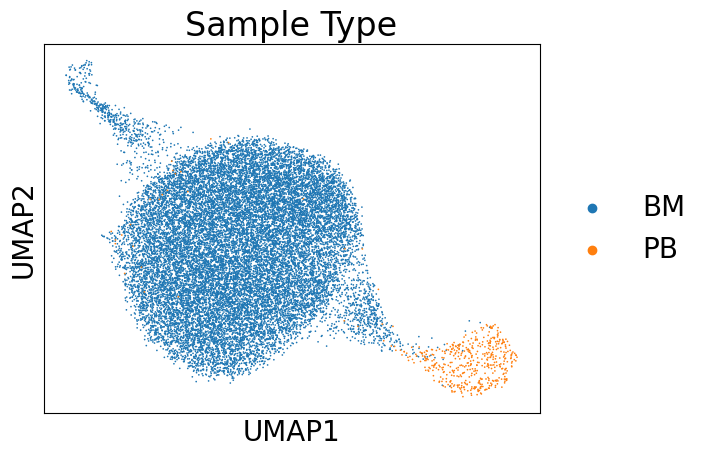

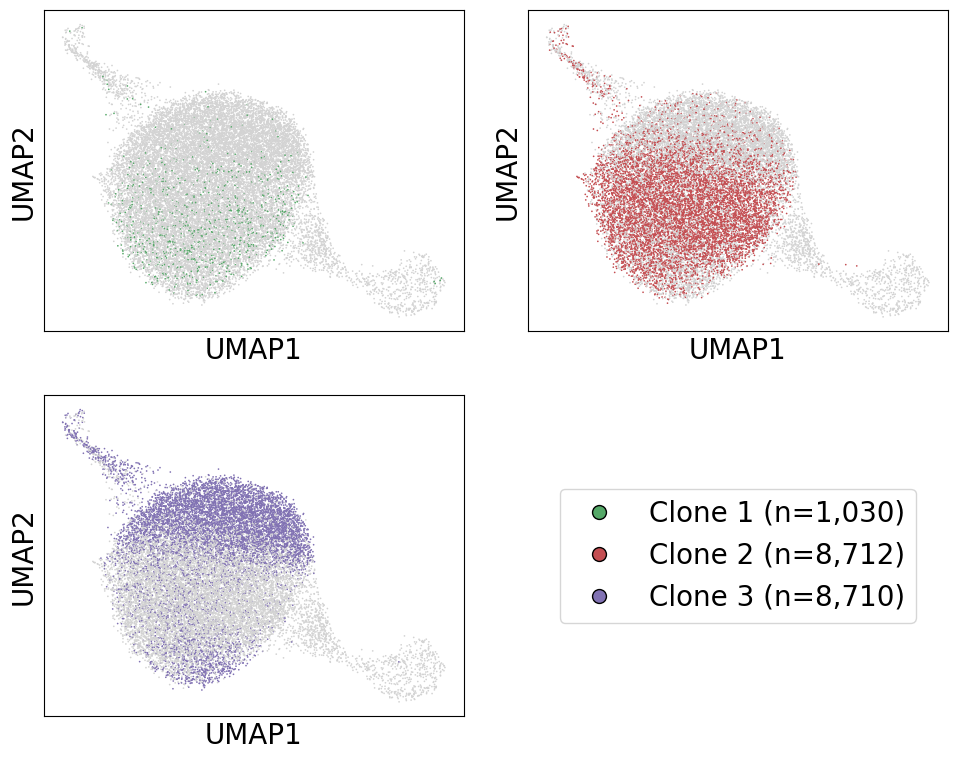

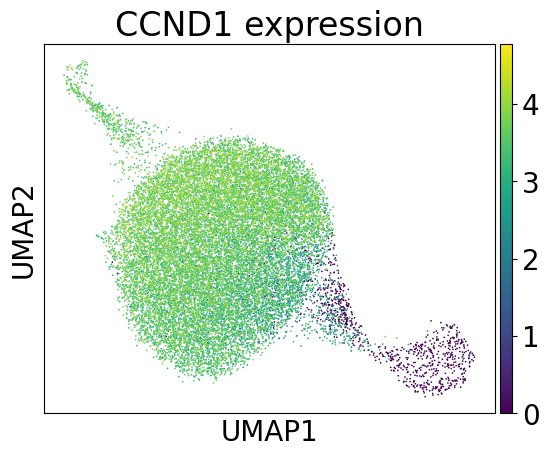

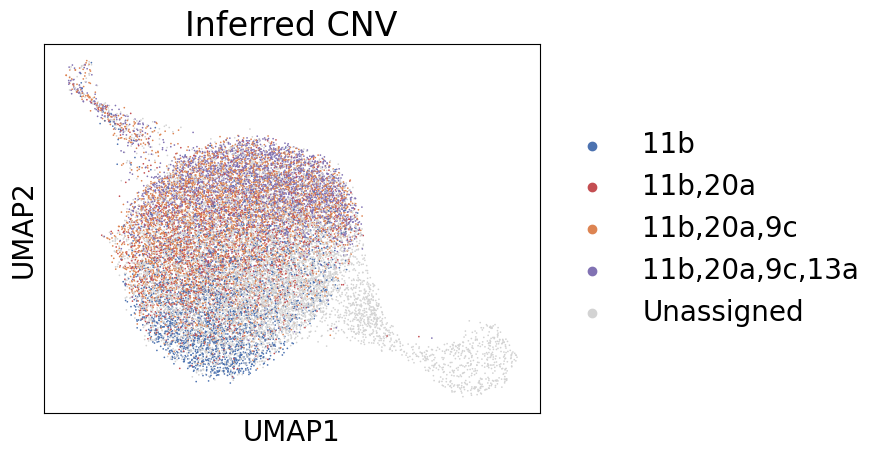

full_cdr3_top3
.-CQSWGTYVVF                 9033
CARHVGSLGPVDYW-.              217
CARHVGSLGPVDYW-CQSWGTYVVF    9827
NaN                          1390
dtype: int64


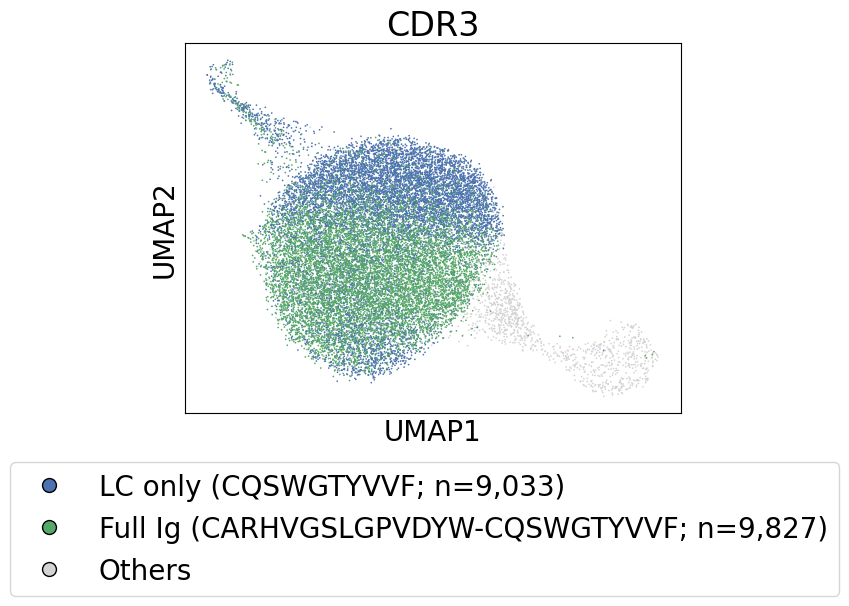

In [1]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import scanpy.external as sce
import os, glob, subprocess, itertools
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import wilcoxon
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from scipy.stats import permutation_test
from scipy.stats import bootstrap
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np

adata = sc.read_h5ad('../data/PCROWD_MM.h5ad')

## CDR3 aa
adata.obs['full_cdr3'] = adata.obs.apply(
    lambda row: (row['heavy_cdr3_aa'] if pd.notna(row['heavy_cdr3_aa']) else '') + '-' + 
                (row['light_cdr3_aa'] if pd.notna(row['light_cdr3_aa']) else ''), 
    axis=1
)
# top3 captures LC only, full chain and HC only (top4 and 5 is small population)
top3_full_cdr3 = adata.obs['full_cdr3'].value_counts().nlargest(3).index
adata.obs['full_cdr3_top3'] = adata.obs['full_cdr3'].apply(lambda x: x if x in top3_full_cdr3 else 'NaN')

cdr3_label_map = {
    '.-CQSWGTYVVF': "LC only (CQSWGTYVVF; n={:,})",
    'CARHVGSLGPVDYW-.': "Others", #"HC only (CARHVGSLGPVDYW; n={:,})",
    'CARHVGSLGPVDYW-CQSWGTYVVF': "Full Ig (CARHVGSLGPVDYW-CQSWGTYVVF; n={:,})"
}

cdr3_counts = adata.obs['full_cdr3_top3'].value_counts()

def get_human_label(cdr3):
    if cdr3 in cdr3_label_map:
        count = cdr3_counts.get(cdr3, 0)
        return cdr3_label_map[cdr3].format(count)
    else:
        return 'Others'

adata.obs['full_cdr3_top3_UMAP'] = adata.obs['full_cdr3_top3'].apply(get_human_label)


## full or light-chain only
adata.obs['heavy_light'] = np.where(
    (adata.obs['heavy_cdr3_aa'] != ".") & (adata.obs['light_cdr3_aa'] != "."), 'full',
    np.where((adata.obs['heavy_cdr3_aa'] == ".") & (adata.obs['light_cdr3_aa'] != "."), 'lc_only', np.nan)
)

# tumor id
adata.obs['TvsN'] = np.where(adata.obs['tumor_id'] == 'tumor', 'T', 'N')


group_map = {
    "<0.2g/L": "Clone 1",
    "≥0.2g/L": "Clone 2",
    "LC MS-MGUS": "Clone 3"
}
adata.obs['MS_group_v2'] = adata.obs['MS_group'].map(group_map)

# Define MS groups
tumor_cond = adata.obs['TvsN'] == 'T'

mgip_mask = tumor_cond & (adata.obs['MS_group'] == '<0.2g/L')
mgus_mask = tumor_cond & (adata.obs['MS_group'] == '≥0.2g/L')
lc_mask = tumor_cond & (adata.obs['MS_group'] == 'LC MS-MGUS')

mgip_count, mgus_count, lc_count = mgip_mask.sum(), mgus_mask.sum(), lc_mask.sum()

mgip_col = f"Clone 1 (n={mgip_count:,})" #f"<0.2g/L (n={mgip_count:,})"
mgus_col = f"Clone 2 (n={mgus_count:,})" #f"≥0.2g/L (n={mgus_count:,})"
lc_col = f"Clone 3 (n={lc_count:,})" #f"LC MS-MGUS (n={lc_count:,})"

## Palette
cdr3_label_map = {
    '.-CQSWGTYVVF': "LC only (CQSWGTYVVF; n={:,})",
    'CARHVGSLGPVDYW-.': "Others", #"HC only (CARHVGSLGPVDYW; n={:,})",
    'CARHVGSLGPVDYW-CQSWGTYVVF': "Full Ig (CARHVGSLGPVDYW-CQSWGTYVVF; n={:,})"
}

def get_human_label(cdr3):
    if cdr3 in cdr3_label_map:
        count = cdr3_counts.get(cdr3, 0)
        return cdr3_label_map[cdr3].format(count)
    else:
        return 'Others'
    
colors = sns.color_palette("deep", n_colors=5)
palette = {'Y' : 'red', 'NaN' : 'lightgrey',
           'N': 'lightgrey', 'T' : colors[1], 
           '≥0.2g/L' : colors[3], 'LC MS-MGUS' : colors[4], '<0.2g/L' : colors[2], 'LC only others' : colors[0],
           mgip_col : colors[2],
           mgus_col : colors[3],
           lc_col : colors[4],
           '.-CQSWGTYVVF':colors[0], 'CARHVGSLGPVDYW-.':colors[1], 'CARHVGSLGPVDYW-CQSWGTYVVF': colors[2]
          } 
cdr3_palette = {
    get_human_label('.-CQSWGTYVVF'): colors[0],
    get_human_label('CARHVGSLGPVDYW-.'): colors[1],
    get_human_label('CARHVGSLGPVDYW-CQSWGTYVVF'): colors[2],
    'Others': 'lightgrey'
}

## Update Numbat results and palette
for ttype in ['GT_opt', 'clone_opt']:
    # Ensure 'Unassigned' is in the category of GT_opt and clone_opt list before using fillna()
    unique_clones = adata.obs[ttype].unique()
    color_map = {
        clone: ("lightgrey" if clone == "Unassigned" else sns.color_palette('deep')[i % len(sns.color_palette('deep'))])
        for i, clone in enumerate(unique_clones)
    }

    palette.update(color_map)


############################ Figures ############################
plt.rcParams.update({'font.size': 20})

## Sample type
fig, ax = plt.subplots()
sc.pl.embedding(adata, basis='X_umap_pca', 
        color = ['sample_type'],
        title='Sample Type',
        ax=ax, show=False
) 
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
fig.savefig('../00.Figures/PCROWD_MM_sampletype.pdf', format='pdf', bbox_inches='tight')
plt.show()


import matplotlib.lines as mlines
# Define a 2x2 subplot structure
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

colors_clone = [mgip_col, mgus_col, lc_col]

# Plot the first three UMAP embeddings
for i, c in enumerate(colors_clone):
    row, col = divmod(i, 2)  # Arrange plots in 2x2 format
    ax = sc.pl.embedding(
            adata,
            basis='X_umap_pca',
            color=c,
            palette=palette,
            ax=axes[row, col],
            title='',
            show=False,
            legend_loc=None 
         )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

# Create the legend in the bottom-right subplot (row=1, col=1)
legend_handles = []
for cat, color in palette.items():
    if cat in colors_clone:
        handle = mlines.Line2D(
            [], [], 
            marker='o', 
            color='w',  
            markerfacecolor=color,
            markeredgecolor='black',  
            linestyle='None', 
            markersize=10,  
            label=cat
        )
        legend_handles.append(handle)

# Remove axis from legend subplot and place the legend there
axes[1, 1].axis("off")  # Hide the empty subplot
axes[1, 1].legend(handles=legend_handles, loc="center", fontsize=20)

plt.tight_layout()
fig.savefig('../00.Figures/PCROWD_MM_MSgroup_v2.pdf', format='pdf', bbox_inches='tight')
plt.show()

# CCND1
fig, ax = plt.subplots()
sc.pl.embedding(adata, basis='X_umap_pca', 
        color = ['CCND1'],
        title='CCND1 expression',
        ax=ax, show=False
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
fig.savefig('../00.Figures/PCROWD_MM_CCND1expressions.pdf', format='pdf', bbox_inches='tight')
plt.show()


## CNV genotype
fig, ax = plt.subplots()
sc.pl.embedding(adata, basis='X_umap_pca', 
        color = ['GT_opt'], palette=palette,
        title='Inferred CNV',
        ax=ax, show=False
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
fig.savefig('../00.Figures/PCROWD_MM_numbatGT.pdf', format='pdf', bbox_inches='tight')
plt.show()


## CDR3
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

print(adata.obs.groupby('full_cdr3_top3').size())
def get_priority(label):
    if 'HC only' in label:
        return 0
    elif 'LC only' in label:
        return 1
    elif 'Full Ig' in label:
        return 2
    else:
        return 3  # Others

all_labels = list(cdr3_palette.keys())

sorted_labels_cdr3 = sorted(all_labels, key=get_priority)

fig, ax = plt.subplots()
sc.pl.embedding(adata, basis='X_umap_pca', 
            color = ['full_cdr3_top3_UMAP'], palette=cdr3_palette,
            title='CDR3',
            ax=ax, show=False,
            legend_loc=None  
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

legend_elements_cdr3 = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=cdr3_palette[label], markersize=10, markeredgecolor='black')
    for label in sorted_labels_cdr3
]

fig.legend(
    handles=legend_elements_cdr3,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.3),  
    ncol=1,  
    fontsize=20,
    frameon=True, #edgecolor='black'
)

fig.savefig('../00.Figures/PCROWD_MM_CDR3top5.pdf', format='pdf', bbox_inches='tight')
plt.show()


11478.63350    17422
11442.60217     1223
11465.12083      205
11629.73576       35
11354.39028       10
11932.72957        9
11571.11205        8
11620.21812        8
12046.78917        5
11402.03845        5
Name: est_mz_ratio, dtype: int64


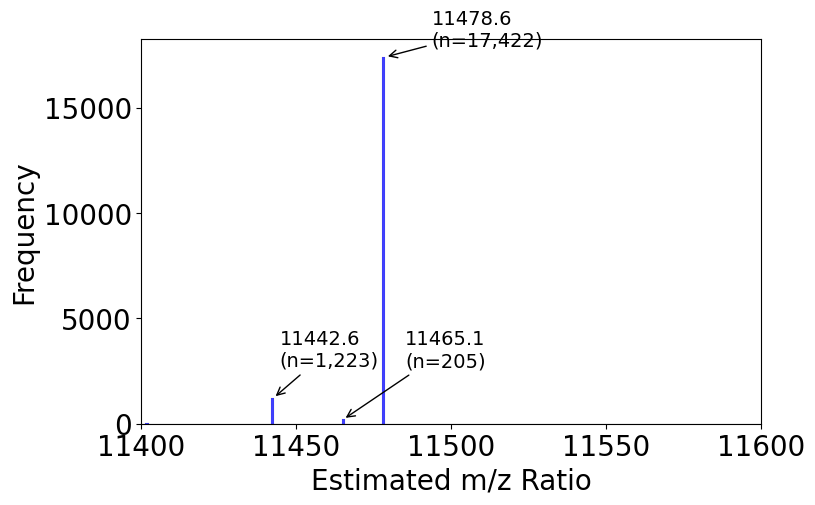

In [2]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import scanpy.external as sce
import os, glob, subprocess, itertools
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import wilcoxon
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from scipy.stats import permutation_test
from scipy.stats import bootstrap
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np

adata = sc.read_h5ad('../data/PCROWD_MM.h5ad')

est_mz_ratio_counts = adata.obs['est_mz_ratio'].value_counts()

top_duplicates_10 = est_mz_ratio_counts.head(10)
top_duplicates_3 = est_mz_ratio_counts.head(3)
print(top_duplicates_10)

# Drop NA values if any
mz_values = adata.obs['est_mz_ratio'].dropna()

plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 20})
sns.histplot(mz_values, bins=1000, kde=False, color='blue')  # kde=True adds a density curve
plt.xlabel('Estimated m/z Ratio')
plt.ylabel('Frequency')

plt.xlim(11400, 11600)

# 3. Annotate top 3 duplicates on the plot
offsets = [(15, 500), (2, 1500), (20, 2500)]  # (x_offset, y_offset) per point

for i, (mz_val, count) in enumerate(top_duplicates_3.items()):
    dx, dy = offsets[i]
    plt.annotate(
        f"{mz_val:.1f}\n(n={count:,})",     # text
        xy=(mz_val, count),               # arrow tip (x, y)
        xytext=(mz_val + dx, count + dy), # text position offset
        textcoords='data',
        arrowprops=dict(arrowstyle="->", color='black'),
        fontsize=14,
        ha='left'
    )

plt.savefig(f'../00.Figures/PCROWD_MM_est_mz_ratio_distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()

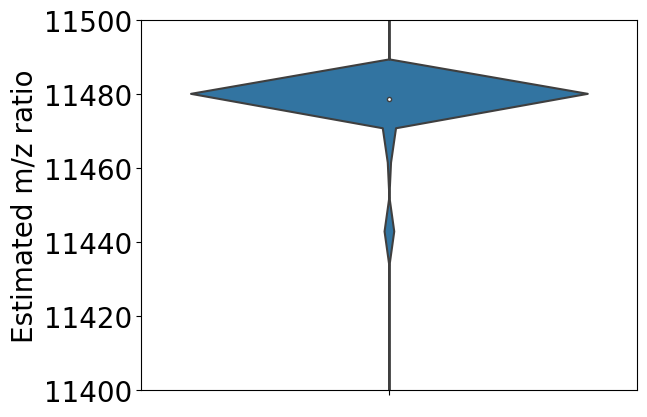

est_mz_ratio
11318.34828       1
11366.88014       1
11379.96337       1
11417.53808       1
11442.60217     187
11465.12083     135
11478.63350    8710
11520.53858       1
11521.16344       1
11540.11954       1
11626.28982       1
11639.80502       1
11645.32879       1
11648.30944       1
11649.79489       1
11654.83708       1
11655.80442       1
11656.83308       1
11664.34033       1
11665.29118       1
11667.87802       1
11684.86629       1
11735.84767       1
11748.95485       1
11751.45981       1
11802.51317       1
11807.45028       1
11942.18820       1
12178.38887       1
12211.48415       1
12228.49226       1
dtype: int64
est_mz_ratio
11318.34828    0.000110
11366.88014    0.000110
11379.96337    0.000110
11417.53808    0.000110
11442.60217    0.020640
11465.12083    0.014901
11478.63350    0.961369
11520.53858    0.000110
11521.16344    0.000110
11540.11954    0.000110
11626.28982    0.000110
11639.80502    0.000110
11645.32879    0.000110
11648.30944    0.000110
11649

In [3]:


filt_df = adata.obs[adata.obs['heavy_light'] == 'lc_only']

plt.rcParams.update({'font.size': 20})

sns.violinplot(y=filt_df['est_mz_ratio']) #, color='white', alpha=0.5,inner=None,)
# sns.stripplot(y=filt_df['est_mz_ratio'], color="black", 
#                       dodge=True, jitter=True, alpha=0.6, size=4)

plt.ylabel('Estimated m/z ratio')


plt.ylim(11400, 11500)
plt.savefig(f'../00.Figures/PCROWD_MM_LC_only_est_mz_ratio.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Count occurrences of each 'est_mz_ratio' value
mz_counts = filt_df.groupby('est_mz_ratio').size()

# Normalize to get fractions
mz_fractions = mz_counts / mz_counts.sum()

# Display the result
print(mz_counts)
print(mz_fractions)



# 04. LC V(D)J-seq analysis

lc 8710
mgip 1030
mgus 8712
normal 1389
types
Clone 1             1030
Clone 2             8712
Clone 3             8710
normal              1389
unassigned tumor     626
dtype: int64


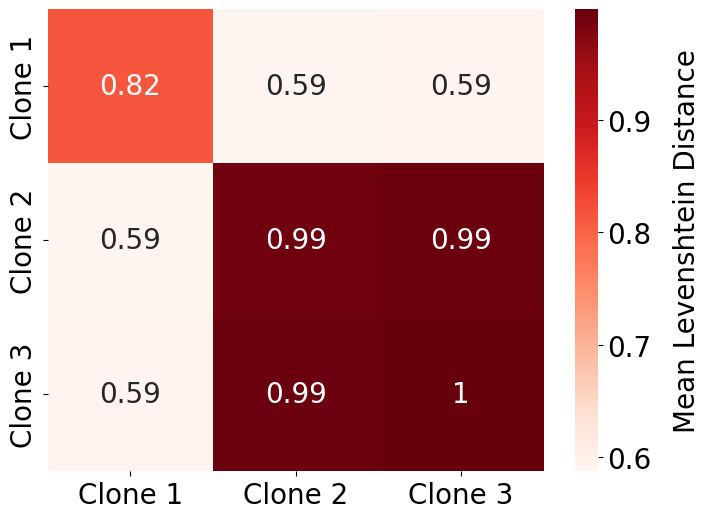

Processing column: full_aa_seq_filt_VDJ
Root - 0: 0.1178
Root - 1: 0.1023

========== Alignment against Root (Root) ==========

Root:    QLVLTQSPSASASLGASVKLTCTLSSGHSSYAIAWHQQQPEKGPRYLMKLNSDGSHSKGDGIPDRFSGSSSGAERYLTIS
0       : .V....L...................E..................F...V.G....N..A....................
1       : .V....L......................................F...V.G....N..A....................

Root:    SLQSEDEADYYCQTWGTGI--
0       : ..........L..S...YVVF
1       : ..........L..S...YVVF



<Figure size 2000x800 with 0 Axes>

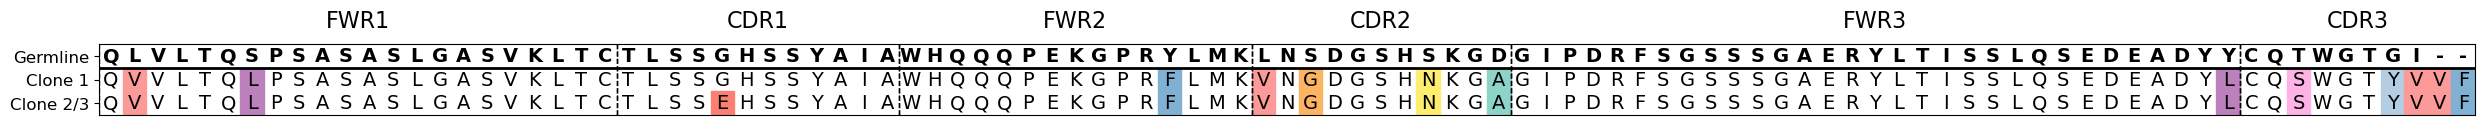

In [8]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import scanpy as sc
from Bio import SeqIO, Phylo
from Bio.Seq import Seq
from io import StringIO
from Bio import AlignIO
from Bio.SeqRecord import SeqRecord
from Bio.Align.Applications import ClustalwCommandline
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, to_tree
from Bio.Phylo.Newick import Tree, Clade
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import to_rgba
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.gridspec as gridspec
from sklearn.metrics import pairwise_distances
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import Levenshtein
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from Bio.Align import AlignInfo
from Bio.Phylo.TreeConstruction import DistanceCalculator


adata = sc.read_h5ad('../data/PCROWD_MM.h5ad')

mgip_col = f"Clone 1 (n=1,030)" #f"<0.2g/L (n={mgip_count:,})"
mgus_col = f"Clone 2 (n=8,712)" #f"≥0.2g/L (n={mgus_count:,})"
lc_col = f"Clone 3 (n=8,710)" #f"LC MS-MGUS (n={lc_count:,})"

lc_barcodes = adata.obs[adata.obs[lc_col] == lc_col].index.tolist()
mgip_barcodes = adata.obs[adata.obs[mgip_col] == mgip_col].index.tolist()
mgus_barcodes = adata.obs[adata.obs[mgus_col] == mgus_col].index.tolist()
normal_barcodes = adata.obs[adata.obs['tumor_id'] == 'N'].index.tolist()

clone_dict = dict(zip(adata.obs['barcode'], adata.obs['clone_opt']))

barcode_dict = {
    'lc': lc_barcodes,
    'mgip': mgip_barcodes,
    'mgus': mgus_barcodes,
    'normal': normal_barcodes
}

for name, interest_list in barcode_dict.items():
    print(name, len(interest_list))


vdj_df = pd.read_csv('../data/PCROWD_MM_BCR.csv', sep=",")
vdj_df['barcode'] = vdj_df['Unnamed: 0']
vdj_df['mz_ratio'] = vdj_df['est_mz_ratio']

valid_barcodes = set(adata.obs.index)
vdj_df_filtered = vdj_df[vdj_df['barcode'].isin(valid_barcodes)]

def categorize_barcode(barcode):
    if barcode in lc_barcodes:
        return 'Clone 3'#'LC MS-MGUS'
    elif barcode in mgip_barcodes:
        return 'Clone 1' #'<0.2g/L'
    elif barcode in mgus_barcodes:
        return 'Clone 2' #'≥0.2g/L'
    elif barcode in normal_barcodes:
        return 'normal'
    else:
        return 'unassigned tumor'

# Create new dataframe
new_df = vdj_df_filtered[['barcode', 'vdj_nt', 'full_aa_seq_filt', 'mz_ratio']].copy()
new_df['types'] = new_df['barcode'].apply(categorize_barcode)
new_df['clone_cnv'] = new_df['barcode'].map(clone_dict)

anchor = "GGGTKLTVL"

def extract_vdj_prefix(seq, anchor):
    if not isinstance(seq, str) or pd.isna(seq):
        return seq
    idx = seq.find(anchor)
    return seq[:idx] if idx != -1 else seq  

new_df['full_aa_seq_filt_VDJ'] = new_df['full_aa_seq_filt'].apply(lambda x: extract_vdj_prefix(x, anchor))

print(new_df.groupby('types').size())

seq_col = "vdj_nt"
#seq_col = "full_aa_seq_filt"


############################# Levenshtein
### add germline
germ_nt = "CAGCTTGTGCTGACTCAATCGCCCTCTGCCTCTGCCTCCCTGGGAGCCTCGGTCAAGCTCACCTGCACTCTGAGCAGTGGGCACAGCAGCTACGCCATCGCATGGCATCAGCAGCAGCCAGAGAAGGGCCCTCGGTACTTGATGAAGCTTAACAGTGATGGCAGCCACAGCAAGGGGGACGGGATCCCTGATCGCTTCTCAGGCTCCAGCTCTGGGGCTGAGCGCTACCTCACCATCTCCAGCCTCCAGTCTGAGGATGAGGCTGACTATTACTGTCAGACCTGGGGCACTGGCATT"
germ_aa = "QLVLTQSPSASASLGASVKLTCTLSSGHSSYAIAWHQQQPEKGPRYLMKLNSDGSHSKGDGIPDRFSGSSSGAERYLTISSLQSEDEADYYCQTWGTGI"

new_row = {
    'types': 'germline',
    'vdj_nt': germ_nt,  
    'full_aa_seq_filt_VDJ': germ_aa, 
    'barcode': 'GERMLINE_REF'  
}
new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)





### assign col
seq_col = "vdj_nt"
#seq_col = "full_aa_seq_filt"
type_col = "types"

### change names
new_df['sample'] = new_df['barcode'].str.split("_1_").str[-1].str.split("_CD").str[0]

type_label_map = {
    "Clone 1"        : "MGIP Clone",
    "Clone 2"        : "MGUS Clone",
    "Clone 3"        : "LC-MGUS Clone",
    "germline"       : "Germline",
    "unassigned tumor": "Unassigned tumor",
    "normal"         : "Normal PC",
}
new_df["display_type"] = new_df[type_col].map(type_label_map).fillna(new_df[type_col])

# is_normal = new_df['types'] == 'normal'
# new_df.loc[is_normal & new_df['sample'].str.contains('PB', na=False), 'new_types'] = 'normal PC in PB'
# new_df.loc[is_normal & new_df['sample'].str.contains('BM', na=False), 'new_types'] = 'normal PC in BM'

TYPE_COLORS = {
    "MGIP Clone"      : "#E63946",
    "MGUS Clone"      : "#F4A261",
    "LC-MGUS Clone"   : "#2A9D8F",
    "Germline"        : "#333333",
    "Unassigned tumor": "#A8DADC",
    "Normal PC"       : "#457B9D",
}
DEFAULT_COLOR = "#AAAAAA"

type_col = 'new_types'

# Group sequences by types and calculate pairwise similarity mean per type
grouped_sequences = new_df.groupby("types")[seq_col].unique()

# Create mapping of types to their sequences
type_to_sequences = {group: list(sequences) for group, sequences in grouped_sequences.items()}
type_names = ['Clone 1', 'Clone 2', 'Clone 3', ] #list(type_to_sequences.keys())
num_types = len(type_names)

# Initialize similarity matrices for mean similarity calculations
levenshtein_matrix = np.zeros((num_types, num_types))
cosine_matrix = np.zeros((num_types, num_types))

# Get sequence counts per type for weighted similarity computation
seq_counts = new_df.groupby(["types", seq_col]).size().reset_index(name="count")

# Create a mapping of sequence counts
seq_count_dict = {(row["types"], row[seq_col]): row["count"] for _, row in seq_counts.iterrows()}

# Compute pairwise similarity mean per type group
for i, type1 in enumerate(type_names):
    for j, type2 in enumerate(type_names):
        if i <= j:  # Compute only once (symmetric matrix)
            seqs1 = type_to_sequences[type1]
            seqs2 = type_to_sequences[type2]

            # Compute Levenshtein distances
            lev_distances = np.array([
                [Levenshtein.distance(seq1, seq2) for seq2 in seqs2] for seq1 in seqs1
            ])
            lev_similarity = 1 - (lev_distances / np.max(lev_distances))

            # Weight similarity by sequence counts
            weight_matrix = np.array([
                [seq_count_dict.get((type1, seq1), 1) * seq_count_dict.get((type2, seq2), 1)
                 for seq2 in seqs2] for seq1 in seqs1
            ])
            weighted_lev_similarity = np.sum(lev_similarity * weight_matrix) / np.sum(weight_matrix)
            levenshtein_matrix[i, j] = levenshtein_matrix[j, i] = weighted_lev_similarity

            # Compute Cosine similarity
            all_sequences = seqs1 + seqs2
            vectorizer = CountVectorizer(analyzer="char", ngram_range=(1, 3))
            X_cosine = vectorizer.fit_transform(all_sequences)
            cosine_sim = 1 - pairwise_distances(X_cosine, metric="cosine")

            # Extract relevant similarity values
            cosine_values = cosine_sim[:len(seqs1), len(seqs1):].flatten()

            # Weight cosine similarity by sequence counts
            weighted_cosine_similarity = np.sum(cosine_values * weight_matrix.flatten()) / np.sum(weight_matrix)
            cosine_matrix[i, j] = cosine_matrix[j, i] = weighted_cosine_similarity

# Convert to DataFrame for visualization
levenshtein_df = pd.DataFrame(levenshtein_matrix, index=type_names, columns=type_names)
cosine_df = pd.DataFrame(cosine_matrix, index=type_names, columns=type_names)

# Plot heatmaps
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 20})
#fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = sns.heatmap(levenshtein_df, annot=True, cmap="Reds")  #, ax=axes[0])
#axes[0].set_title("Weighted Levenshtein Similarity (Mean per Type)")
#sns.heatmap(cosine_df, annot=True, cmap="coolwarm", ax=axes[1])
#axes[1].set_title("Weighted Cosine Similarity (Mean per Type)")

colorbar = ax.collections[0].colorbar  # Get the colorbar object
colorbar.set_label('Mean Levenshtein Distance', labelpad=15)  # Set label and labelpad

plt.savefig(f'../00.Figures/PANGEA_4385_VDJseq_Levenshtein.pdf', bbox_inches='tight')
plt.show()

############################# Visualize 
new_df['types'] = new_df['types'].astype(str)

# remove singletons (normals)
new_df = new_df[new_df.groupby('full_aa_seq_filt')['full_aa_seq_filt'].transform('size') > 100]
# remove unassigned tumors
new_df = new_df[new_df['types'] != 'unassigned tumor']

## Amino acid
root_sequence = "QLVLTQSPSASASLGASVKLTCTLSSGHSSYAIAWHQQQPEKGPRYLMKLNSDGSHSKGDGIPDRFSGSSSGAERYLTISSLQSEDEADYYCQTWGTGI"

clustalw_exe = "/usr/bin/clustalw" 

#for seq_col in ['vdj_nt', 'full_aa_seq_filt']:
#for seq_col in ['vdj_nt']:
for seq_col in ['full_aa_seq_filt_VDJ']:
    print(f"Processing column: {seq_col}")
    # Define unique file names per sequence column
    fasta_file = f"../data/sequences_{seq_col}.fasta"
    aligned_fasta = f"../data/sequences_{seq_col}.aln"
    tree_file = f"../data/sequences_{seq_col}.dnd"
    rooted_tree_file = f"../data/rooted_tree_{seq_col}.newick"

    # 1. Convert DataFrame to FASTA Format
    records = []
    # Add root sequence as a reference (Name germline as 'Root')
    records.append(SeqRecord(Seq(root_sequence), id="Root", description="Root Sequence"))

    # Create FASTA file for the current seq_col
    leaf_name_dict, mz_dict = {}, {}
    for i, seq in enumerate(new_df[seq_col].unique()):
        leaf_name_dict[str(i)] = new_df[new_df[seq_col] == seq]['types'].unique()
        mz_dict[str(i)] = new_df[new_df[seq_col] == seq]['mz_ratio'].unique()
        records.append(SeqRecord(Seq(seq), id=str(i)))

    SeqIO.write(records, fasta_file, "fasta")

    # 1. Run ClustalW for Multiple Sequence Alignment
    clustalw_cline = ClustalwCommandline(clustalw_exe, infile=fasta_file)
    stdout, stderr = clustalw_cline()

    # 2. Generate a Phylogenetic Tree (Unrooted)
    clustalw_cline_tree = ClustalwCommandline(clustalw_exe, infile=fasta_file, tree=True, outfile=tree_file)
    stdout, stderr = clustalw_cline_tree()

    # 3. Root the Tree using the Given Root Sequence
    tree = Phylo.read(tree_file, "newick")
    tree.root_with_outgroup("Root")  # Ensure the root is correctly named in your data (germline='Root')

    # Save the rooted tree
    Phylo.write(tree, rooted_tree_file, "newick")

    # 4. Load the Rooted Tree and Draw It
    tree = Phylo.read(rooted_tree_file, "newick")

    ##### Alignment Check #####
    # 1. Read aligned FASTA file
    alignment = AlignIO.read(aligned_fasta, "clustal")

    alignment = AlignIO.read(aligned_fasta, "clustal")
    calculator = DistanceCalculator('blosum62')
    dm = calculator.get_distance(alignment)

    for i in dm.names:
        if i == 'Root':
            for j in dm.names:
                if i != j:
                    print(f"{i} - {j}: {dm[i, j]:.4f}")


############### Print alignment
from Bio import AlignIO

# ClustalW read
alignment = AlignIO.read(aligned_fasta, "clustal")

# Root sequence 
root_seq = None
for record in alignment:
    if record.id == 'Root':
        root_seq = str(record.seq)
        break
assert root_seq is not None, "Root sequence not found in alignment!"

# Visualize alignment against Root
def visualize_alignment(alignment, root_id='Root', line_width=80):
    root_seq = None
    aligned_records = []
    for record in alignment:
        if record.id == root_id:
            root_seq = str(record.seq)
        else:
            aligned_records.append((record.id, str(record.seq)))

    assert root_seq is not None, "Root sequence not found!"

    print(f"\n{'='*10} Alignment against Root ({root_id}) {'='*10}\n")

    for start in range(0, len(root_seq), line_width):
        print(f"Root:    {root_seq[start:start+line_width]}")
        for rec_id, seq in aligned_records:
            aligned = ''
            for i in range(start, start+line_width):
                if i >= len(seq):
                    break
                if seq[i] == root_seq[i]:
                    aligned += '.'
                elif seq[i] == '-':
                    aligned += '-'
                else:
                    aligned += seq[i]
            print(f"{rec_id:8}: {aligned}")
        print()

visualize_alignment(alignment)
                    
                    
# 1. Define germline subregions
fwr1 = "QLVLTQSPSASASLGASVKLTC"
cdr1 = "TLSSGHSSYAIA"
fwr2 = "WHQQQPEKGPRYLMK"
cdr2 = "LNSDGSHSKGD"
fwr3 = "GIPDRFSGSSSGAERYLTISSLQSEDEADYY"
cdr3 = "CQTWGTGI"
germline_concat = fwr1 + cdr1 + fwr2 + cdr2 + fwr3 + cdr3

# 2. Load alignment
alignment = AlignIO.read("../data/sequences_full_aa_seq_filt_VDJ.aln", "clustal")
aligned_ids = [record.id for record in alignment]
aligned_seqs = [str(record.seq) for record in alignment]

n_seqs = len(aligned_seqs)
seq_len = len(aligned_seqs[0])

# 3. Map germline AAs to alignment positions
germline_aligned = aligned_seqs[aligned_ids.index('Root')]
aa_to_aln_index = []
aa_count = 0
for i, aa in enumerate(germline_aligned):
    if aa != '-':
        aa_to_aln_index.append(i)
        aa_count += 1
        if aa_count == len(germline_concat):
            break

# Get alignment indices for each region
def get_region_indices(start, region):
    region_len = len(region)
    return aa_to_aln_index[start], aa_to_aln_index[start + region_len - 1]

regions = {
    "FWR1": get_region_indices(0, fwr1),
    "CDR1": get_region_indices(len(fwr1), cdr1),
    "FWR2": get_region_indices(len(fwr1)+len(cdr1), fwr2),
    "CDR2": get_region_indices(len(fwr1)+len(cdr1)+len(fwr2), cdr2),
    "FWR3": get_region_indices(len(fwr1)+len(cdr1)+len(fwr2)+len(cdr2), fwr3),
    "CDR3": get_region_indices(len(fwr1)+len(cdr1)+len(fwr2)+len(cdr2)+len(fwr3), cdr3)
}

# 4. Color scheme
aa_colors = {
    'A': '#8dd3c7', 'C': '#ffffb3', 'D': '#bebada', 'E': '#fb8072',
    'F': '#80b1d3', 'G': '#fdb462', 'H': '#b3de69', 'I': '#fccde5',
    'K': '#d9d9d9', 'L': '#bc80bd', 'M': '#ccebc5', 'N': '#ffed6f',
    'P': '#bc80bd', 'Q': '#ffb3b3', 'R': '#b0e0e6', 'S': '#fdb3e6',
    'T': '#bebada', 'V': '#fb9a99', 'W': '#ccebc5', 'Y': '#b3cde3',
    '-': '#ffffff'
}
default_color = '#ffffff'

# 5. Plot
plt.figure(figsize=(20, 8))
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(seq_len * 0.25, n_seqs * 0.9)) 

root_seq = aligned_seqs[aligned_ids.index('Root')]

for i, (sid, row) in enumerate(zip(aligned_ids, aligned_seqs)):
    for j, aa in enumerate(row):
        if sid == 'Root':
            ax.text(j + 0.5, n_seqs - i - 0.5, aa, ha='center', va='center', fontsize=14, fontweight='bold')#color='black')
        else:
            if aa != root_seq[j]:  # Color if different from root
                color = aa_colors.get(aa.upper(), default_color)
                ax.add_patch(plt.Rectangle((j, n_seqs - i - 1), 1, 1, color=color))
            ax.text(j + 0.5, n_seqs - i - 0.5, aa, ha='center', va='center', fontsize=14) #, fontweight='bold')

# 6. Vertical lines and region labels
for label, (start, end) in regions.items():
    ax.axvline(x=start, color='black', linestyle='--', linewidth=1)
    if label == 'CDR3': ## 2 deletion
        #ax.axvline(x=end + 3, color='black', linestyle='--', linewidth=1)
        mid = (start + end + 3) / 2
    else:
        ax.axvline(x=end + 1, color='black', linestyle='--', linewidth=1)
        mid = (start + end + 1) / 2
    ax.text(mid, -0.5, label, ha='center', va='bottom', fontsize=16) #, fontweight='bold')

# 7. Horizontal line separating germline
germline_index = aligned_ids.index('Root')
ax.axhline(y=n_seqs - germline_index, color='black', linestyle='-', linewidth=2)

# 8. Axis setup
id_dict = {'Root': 'Germline', '0': 'Clone 2/3', '1': 'Clone 1'}
aligned_ids_updated = [id_dict.get(k, k) for k in aligned_ids]

ax.set_xlim(0, seq_len)
ax.set_ylim(0, n_seqs)
ax.set_xticks([])
ax.set_yticks(np.arange(0.5, n_seqs + 0.5))
ax.set_yticklabels(aligned_ids_updated[::-1], fontsize=12)
ax.set_aspect('equal')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'../00.Figures/PCROWD_MM_lightchain_AAseq.pdf', bbox_inches='tight')
plt.show()



# 05. CNV probability matrix visualization

,11:11b(amp),20:20a(del),9:9c(amp),13:13a(del)
MS_group_v2,,,,
Clone 1,0.635260,0.376179,0.337489,0.077961
Clone 2,0.701780,0.508113,0.465918,0.131747
Clone 3,0.909553,0.814418,0.777453,0.448493


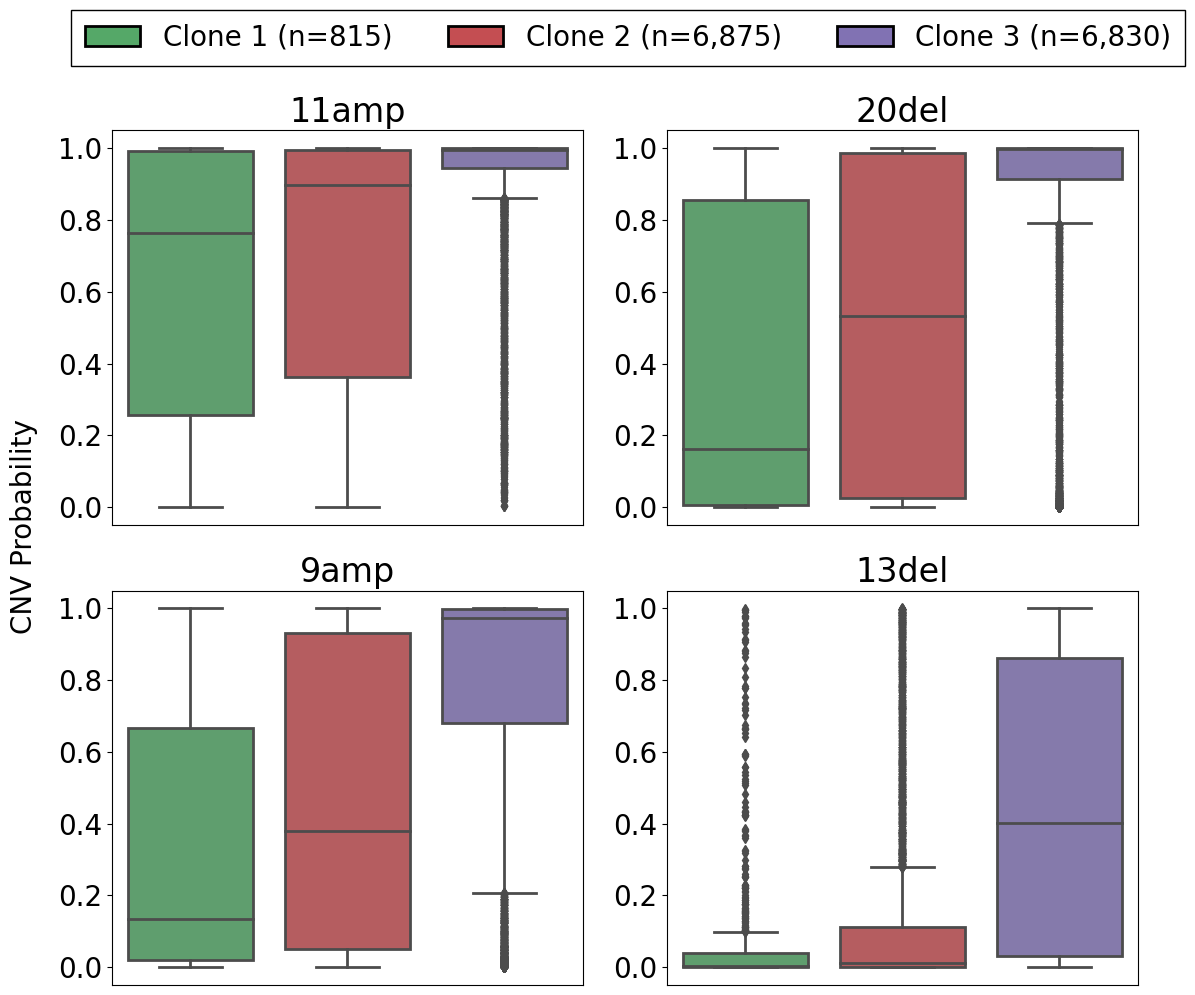

In [9]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import scanpy as sc
from Bio import SeqIO, Phylo
from Bio.Seq import Seq
from io import StringIO
from Bio import AlignIO
from Bio.SeqRecord import SeqRecord
from Bio.Align.Applications import ClustalwCommandline
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, to_tree
from Bio.Phylo.Newick import Tree, Clade
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import to_rgba
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.gridspec as gridspec

adata = sc.read_h5ad('../data/PCROWD_MM.h5ad')

## Load data
numbat_joint_df = pd.read_csv(f'../data/PCROWD_MM_joint_post_2.tsv', sep="\t", index_col='cell')
numbat_seg_df = pd.read_csv(f'../data/PCROWD_MM_segs_consensus_2.tsv', sep="\t")
numbat_clone_df = pd.read_csv(f'../data/PCROWD_MM_clone_post_2.tsv', sep="\t", index_col='cell')


## Create cell X CNV prob matrix (per CNV type)
numbat_joint_df['segment_id'] = numbat_joint_df['CHROM'].astype(str) + ':' + numbat_joint_df['seg_label'].astype(str)

# pivot: rows = cell, columns = segment, values = p_cnv
cnv_matrix = numbat_joint_df.pivot_table(
    index='cell', 
    columns='segment_id', 
    values='p_cnv',
    aggfunc='mean',  
    fill_value=0    
)

#prinit(cnv_matrix)

# Join
sc_data = adata.obs.join(cnv_matrix, how='left')
# Drop non-cnv informative cells
sc_data = sc_data.dropna(subset=cnv_matrix.columns)

# CNV columns and simplified labels
cnv_cols = ['11:11b(amp)', '20:20a(del)', '9:9c(amp)', '13:13a(del)']
label_map = {
    '11:11b(amp)': '11amp',
    '20:20a(del)': '20del',
    '9:9c(amp)': '9amp',
    '13:13a(del)': '13del'
}

ms_order = ['Clone 1', 'Clone 2', 'Clone 3']
subset_data = sc_data[sc_data['MS_group_v2'].isin(ms_order)].copy()
subset_data['MS_group_v2'] = pd.Categorical(subset_data['MS_group_v2'], categories=ms_order, ordered=True)

# Matrix
cnv_mean_matrix = subset_data.groupby('MS_group_v2')[cnv_cols].mean()
display(cnv_mean_matrix)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.rcParams.update({'font.size': 20})
axes = axes.flatten()

colors = sns.color_palette("deep", n_colors=5)
color_map = {
    'Clone 1': colors[2],
    'Clone 2': colors[3],
    'Clone 3': colors[4],
}

# Clone count
clone_counts = subset_data['MS_group_v2'].value_counts().to_dict()

for i, col in enumerate(cnv_cols):
    sns.boxplot(
        data=subset_data,
        x='MS_group_v2',
        y=col,
        ax=axes[i],
        palette=color_map,
        linewidth=2,
    )
    
    
    axes[i].set_title(f'{label_map[col]}')
    axes[i].set_xlabel("")  
    axes[i].set_ylabel("") 
    axes[i].set_xticks([]) 


#fig.text(0.54, 0.035, 'MS Group', ha='center', fontsize=16)
fig.text(0.035, 0.54, 'CNV Probability', va='center', rotation='vertical')


legend_elements = []
for clone in ['Clone 1', 'Clone 2', 'Clone 3']:
    count = clone_counts.get(clone, 0)
    label = f'{clone} (n={count:,})'
    patch = Patch(
        facecolor=color_map[clone],
        edgecolor='black',    
        linewidth=2,     
        label=label
    )
    legend_elements.append(patch)

fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.55, 1.07), 
    ncol=3, 
    fontsize=20,
    frameon=True,                
    edgecolor='black',        
    framealpha=1.0,            
    borderpad=0.5,             
    fancybox=False             
)


plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.savefig('../00.Figures/PCROWD_MM_CNVprob_boxplots.pdf', format='pdf', bbox_inches='tight')
plt.show()




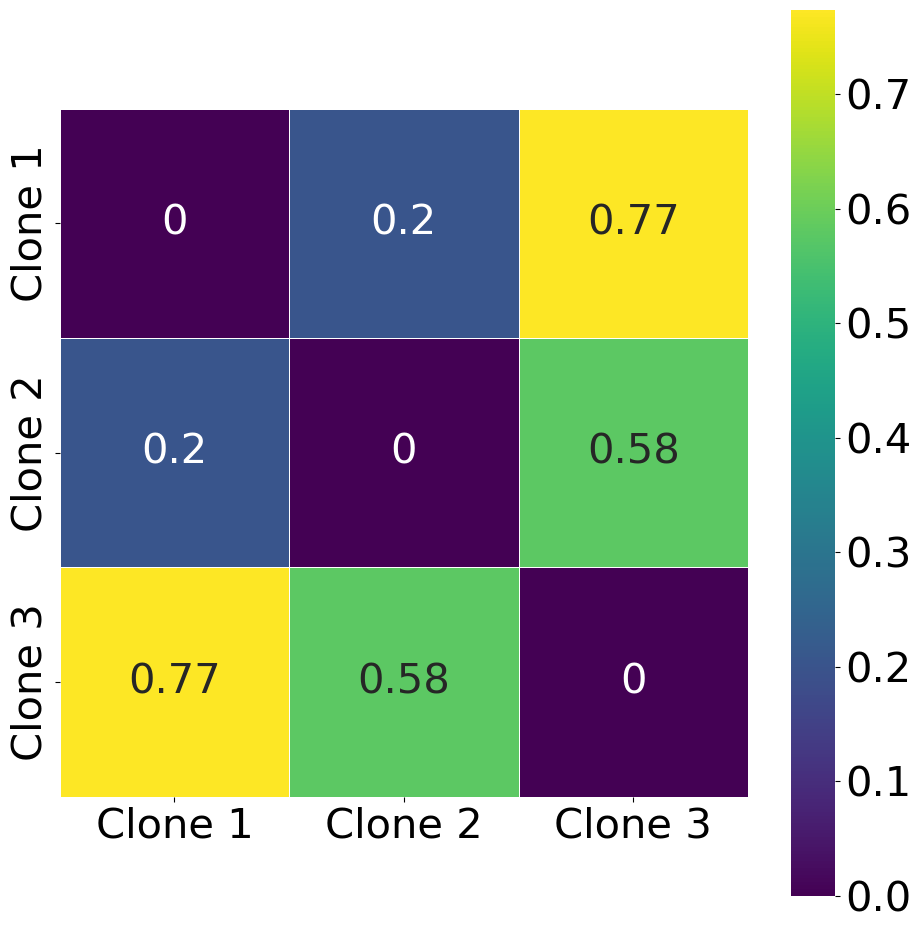

In [10]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt

cnv_cols = [
    '11:11b(amp)',
    '20:20a(del)',
    '9:9c(amp)',
    '13:13a(del)'
            ]

#cnv_only = sc_data[cnv_matrix.columns]
cnv_only = sc_data[cnv_cols]

group_mean_matrix = cnv_only.groupby(sc_data['MS_group_v2']).mean()

ordered_groups = ['Clone 1', 'Clone 2', 'Clone 3']

group_mean_matrix_ordered = group_mean_matrix.loc[ordered_groups]

dist_mat_ordered = pd.DataFrame(
    squareform(pdist(group_mean_matrix_ordered, metric='euclidean')),
    index=ordered_groups,
    columns=ordered_groups
)

plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 30})
sns.heatmap(dist_mat_ordered, annot=True, cmap='viridis', square=True, 
            cbar=True, linewidths=0.5)
plt.tight_layout()
plt.savefig(f'../00.Figures/PCROWD_MM_CNVprob_Euclidean_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()




# 06. Schematic diagram

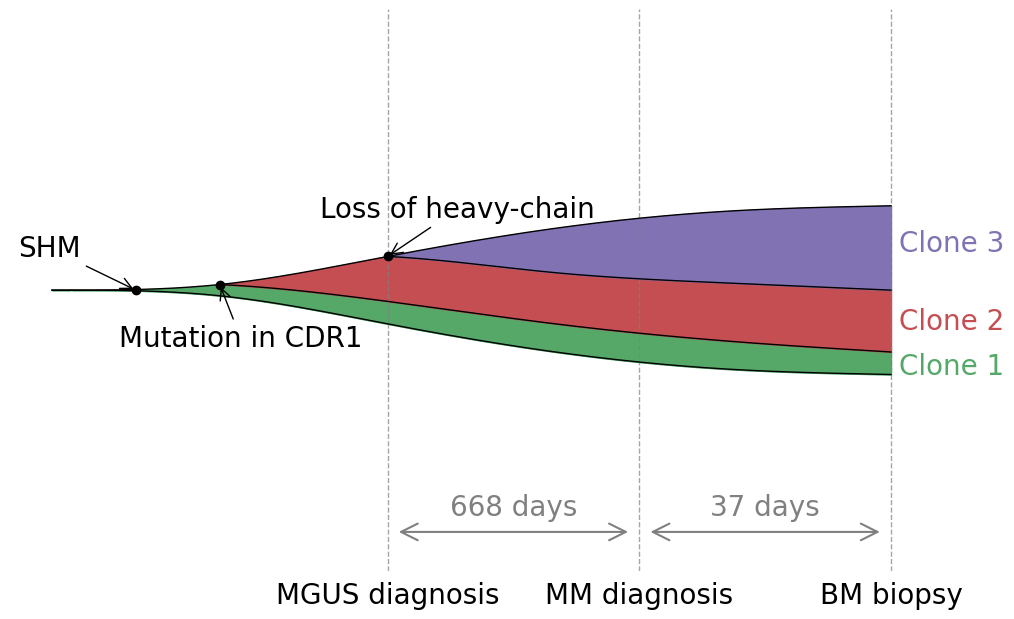

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

def create_smooth_curve(x_base, y_base, x_smooth):
    x_base = np.array(x_base)
    y_base = np.array(y_base)
    k = min(3, len(x_base) - 1)

    spline = make_interp_spline(x_base, y_base, k=k, bc_type='natural')
    return spline(x_smooth)


x_base = np.array([0, 1, 2, 3, 4, 5])
x_smooth = np.linspace(x_base.min(), x_base.max(), 500)

# 1. Upper & lower outer bounds
y_upper_base = np.array([0.0, 0.01, 0.06, 0.11, 0.14, 0.15])
y_upper = create_smooth_curve(x_base, y_upper_base, x_smooth)
y_lower = -y_upper

# 2. Clone #2 defining lineage x=1~5 
y_red = np.array([0.01, 0.01, -0.02, -0.06, -0.09, -0.11])
red_lineage_line = create_smooth_curve(x_base, y_red, x_smooth)

# 3. Clone #3 (purple): x=2~5 
y_purple = np.array([0.06, 0.06, 0.06, 0.031, 0.013, 0.0])
purple_lineage_line = create_smooth_curve(x_base, y_purple, x_smooth)

# Draw chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("deep", n_colors=5)
color_map = {
    'Clone 1': colors[2],
    'Clone 2': colors[3],
    'Clone 3': colors[4],
}


for i in range(len(x_smooth) - 1): 
#for i in range(20,21):
    xs = [x_smooth[i], x_smooth[i + 1]]
    yl = [y_lower[i], y_lower[i + 1]]
    yu = [y_upper[i], y_upper[i + 1]]
    yr = [red_lineage_line[i], red_lineage_line[i + 1]]
    yp = [purple_lineage_line[i], purple_lineage_line[i + 1]]
    
    if 0<= x_smooth[i] < 1: ## first part
        ax.fill_between(xs, yl, yu, color=color_map['Clone 1'])
    
    elif 1 <= x_smooth[i] < 2:
        ax.fill_between(xs, yl, yr, color=color_map['Clone 1'])
        ax.fill_between(xs, yr, yu, color=color_map['Clone 2'])

    elif 2 <= x_smooth[i] < 5:
        ax.fill_between(xs, yl, yr, color=color_map['Clone 1'])
        ax.fill_between(xs, yr, yp, color=color_map['Clone 2'])
        ax.fill_between(xs, yp, yu, color=color_map['Clone 3'])


ax.plot(x_smooth, y_upper, color='black', linewidth=1)
ax.plot(x_smooth, y_lower, color='black', linewidth=1)
ax.plot(x_smooth[100:], red_lineage_line[100:], color='black', linewidth=1)
ax.plot(x_smooth[200:], purple_lineage_line[200:], color='black', linewidth=1)

# Show axis
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel("Timepoint", fontsize=12)
ax.set_ylabel("Relative Value", fontsize=12)

ax.set_ylim(-0.5, 0.5)  # Set limits from -1 to 1

# Annotation
ax.plot(0.5, 0.0, 'o', color='black')  # Dot
ax.annotate("SHM", xy=(0.5, 0.0), xytext=(-0.2, 0.06),
             arrowprops=dict(arrowstyle="->"), fontsize=20)

ax.plot(1, 0.01, 'o', color='black')  # Dot
ax.annotate("Mutation in CDR1", xy=(1, 0.01), xytext=(0.4, -0.1),
             arrowprops=dict(arrowstyle="->"), fontsize=20)

ax.plot(2, 0.06, 'o', color='black')
ax.annotate("Loss of heavy-chain", xy=(2, 0.06), xytext=(1.6, 0.13),
             arrowprops=dict(arrowstyle="->"), fontsize=20)

# Clone annotation
ax.text(5.05, -0.15, "Clone 1", color = color_map['Clone 1'], fontsize=20)
ax.text(5.05, -0.07, "Clone 2", color = color_map['Clone 2'], fontsize=20)
ax.text(5.05, 0.07, "Clone 3", color = color_map['Clone 3'], fontsize=20)

#ax.axis('off')

# 2. x-label custom
#xticks = [0.5, 2, 3.5, 5]
xticks = [2, 3.5, 5]
xtick_labels = [
    "MGUS diagnosis", #"11/01/2019\nMGUS diagnosis", 
    "MM diagnosis", #"08/30/2021\nMM diagnosis", 
    "BM biopsy",#"10/06/2021\nBM biopsy"
]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=20)


table_df = pd.DataFrame({
    "11/01/2019": ["0.2g/dL", "IgA Lambda", "NA", "NA"],
    "08/30/2021": ["Not quantifiable", "IgA Lambda", "0.01 (High Lambda)", "NA"],
    "10/06/2021": ["Not quantifiable", "IgA Lambda", "0.01 (High Lambda)", 
                   "IgA Lambda (0.58g/L)\n& IgA (0.068g/L)"],
}, index=["SPEP", "IFX", "FLC", "MS"])

## Add days
date_dict = {
    "11/01/2019": pd.to_datetime("2019-11-01"),
    "08/30/2021": pd.to_datetime("2021-08-30"),
    "10/06/2021": pd.to_datetime("2021-10-06")
}

days_1 = (date_dict["08/30/2021"] - date_dict["11/01/2019"]).days
days_2 = (date_dict["10/06/2021"] - date_dict["08/30/2021"]).days

ax.annotate(
    "", xy=(3.45, -0.43), xytext=(2.05, -0.43),
    arrowprops=dict(arrowstyle="<->", color='gray', linewidth=1.5)
)
ax.text(2.75, -0.36, f"{days_1} days", ha='center', va='top', fontsize=20, color='gray')

ax.annotate(
    "", xy=(4.95, -0.43), xytext=(3.55, -0.43),
    arrowprops=dict(arrowstyle="<->", color='gray', linewidth=1.5)
)
ax.text(4.25, -0.36, f"{days_2} days", ha='center', va='top', fontsize=20, color='gray')

# Remove plot spline, tick, labels
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, right=False, top=False, bottom=False)
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
#ax.grid(False)
ax.grid(True, linestyle='--', linewidth=1, alpha=0.7, color='gray')

fig.tight_layout(pad=0)
plt.savefig('../00.Figures/PANGEA_4385_hypothetical_schematic_diagram.pdf', format='pdf', bbox_inches='tight')
plt.show()